<a href="https://colab.research.google.com/github/RamcharanChandragiri/MACHINE-LEARNING/blob/main/ML_Lab_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SUBTASK-01**

AdaBoost Implementation: Using AdaBoost from libraries and comparing
classification results with a single Decision Tree.

Kaggle Dataset Link: https://www.kaggle.com/competitions/titanic?

Tasks:
1. Load the dataset and preprocess:
Handle missing values (Age)
Encode categorical features (Sex, Embarked)
2. Train a single Decision Tree classifier.
3. Train an AdaBoost classifier using Decision Tree (stump) as base estimator.
4. Compare both models using:
Accuracy
Precision, Recall, F1-score
5. Plot and compare confusion matrices


In [ ]:
#loading the required libraries , loading the dataset and preprocessing
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("titanic_train.csv")

df.head()

df['Age'].fillna(df['Age'].median(), inplace=True)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Embarked'] = le.fit_transform(df['Embarked'])
X = df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

/tmp/ipykernel_194/1465758949.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_194/1465758949.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
#training the single decision tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [ ]:
#training an adboost classifier
stump = DecisionTreeClassifier(max_depth=1)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

In [ ]:
#evaluating the accuracy, precision, recall and F1 score of both the models
print("Decision Tree Metrics")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))

print("AdaBoost Metrics")

print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1-score:", f1_score(y_test, y_pred_ada))

Decision Tree Metrics
Accuracy: 0.7821229050279329
Precision: 0.7215189873417721
Recall: 0.7702702702702703
F1-score: 0.7450980392156863
AdaBoost Metrics
Accuracy: 0.7932960893854749
Precision: 0.7605633802816901
Recall: 0.7297297297297297
F1-score: 0.7448275862068966


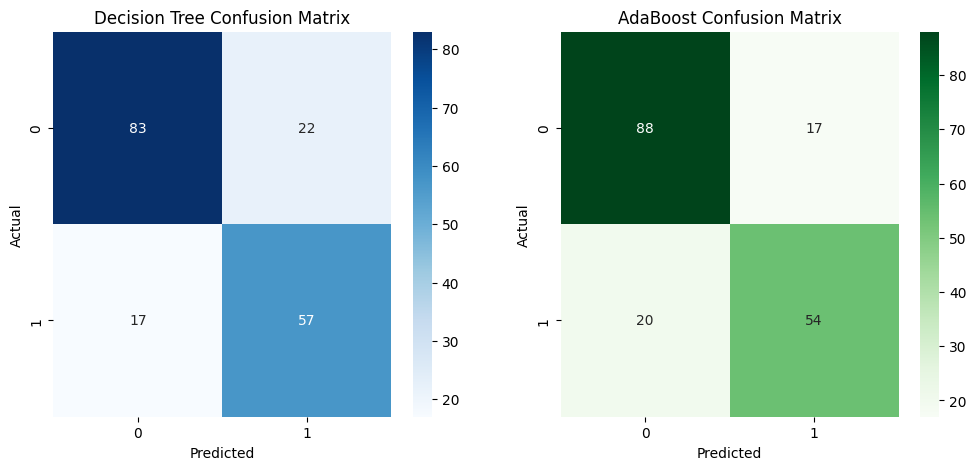

In [ ]:
#plotting the confusion matrices
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_ada = confusion_matrix(y_test, y_pred_ada)

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Decision Tree Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("AdaBoost Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

**SUBTASK-02**

AdaBoost Implementation: Using AdaBoost from libraries and comparing
classification results with a single Decision Tree.

Kaggle Dataset Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?

Tasks:
1. Load dataset and encode target (Malignant, Benign).
2. Split data into train/test sets (80/20).
3. Train:
Decision Tree classifier
AdaBoost classifier
4. Compare models using:
Accuracy
ROC-AUC score
5. Conclude how boosting improves classification performance.


In [ ]:
#loading the dataset , preprocessing it and encoding the target
df = pd.read_csv("data.csv")

df.head()
le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])
X = df.drop(['diagnosis','id', 'Unnamed: 32'], axis=1)
y = df['diagnosis']

In [ ]:
#splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.impute import SimpleImputer

#training the decision classifier and adboost classifier

# Handle missing values in X_train and X_test
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame, retaining column names
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns)

#Decision classifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

#AdaBoost classifier

stump = DecisionTreeClassifier(max_depth=1)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

y_prob_ada = ada_model.predict_proba(X_test)[:,1]

In [ ]:
print(len(y_test))
print(len(y_pred_dt))
print(len(y_pred_ada))

179
179
179


In [ ]:
#comparing the models
#accuracy_score
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_ada = accuracy_score(y_test, y_pred_ada)

print("Decision Tree Accuracy:", acc_dt)
print("AdaBoost Accuracy:", acc_ada)

#roc_score

roc_dt = roc_auc_score(y_test, y_prob_dt)
roc_ada = roc_auc_score(y_test, y_prob_ada)

print("Decision Tree ROC-AUC:", roc_dt)
print("AdaBoost ROC-AUC:", roc_ada)

Decision Tree Accuracy: 0.7821229050279329
AdaBoost Accuracy: 0.7932960893854749
Decision Tree ROC-AUC: 0.8001930501930501
AdaBoost ROC-AUC: 0.8643500643500643


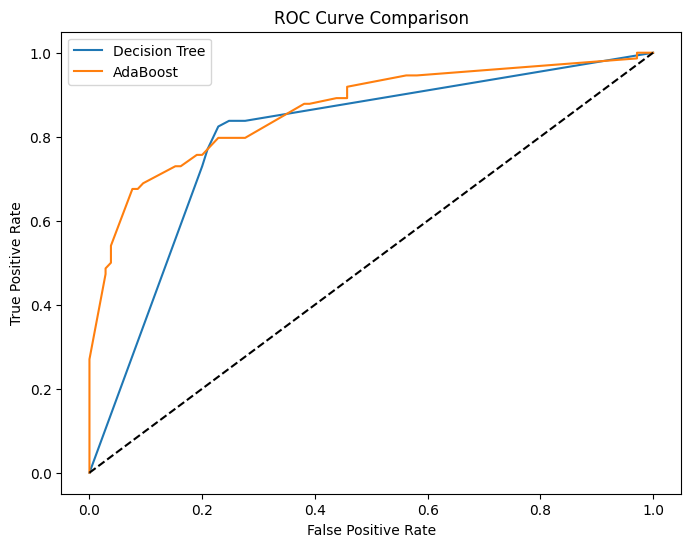

In [ ]:
#plotting thr ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)

plt.figure(figsize=(8,6))

plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

**SUBTASK-03**

AdaBoost Implementation: Using AdaBoost from libraries and comparing
classification results with a single Decision Tree.

Kaggle Dataset Link: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?

Tasks:
1. Load and preprocess the dataset.
2. Train AdaBoost classifiers with different n_estimators:
10, 50, 100, 200
3. Evaluate each model using:
Accuracy
F1-score
4. Plot n_estimators vs Accuracy.
5. Identify the optimal number of estimators and justify.


In [ ]:
#loading and preproessing the dataset
df = pd.read_csv("heart_disease_uci.csv")

df.head()
df = df.dropna()
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
X = df.drop("num", axis=1)
y = df["num"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#adboost classifiers with multiple estimators
estimators = [10, 50, 100, 200]

accuracy_scores = []
f1_scores = []

for n in estimators:

    stump = DecisionTreeClassifier(max_depth=1)

    model = AdaBoostClassifier(
        estimator=stump,
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # Corrected: Added average='weighted'

    accuracy_scores.append(acc)
    f1_scores.append(f1)

    print("n_estimators =", n)
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print()

n_estimators = 10
Accuracy: 0.6166666666666667
F1-score: 0.5207818930041151

n_estimators = 50
Accuracy: 0.5666666666666667
F1-score: 0.5556277056277056

n_estimators = 100
Accuracy: 0.5833333333333334
F1-score: 0.6011842563566702

n_estimators = 200
Accuracy: 0.6
F1-score: 0.5974545454545453



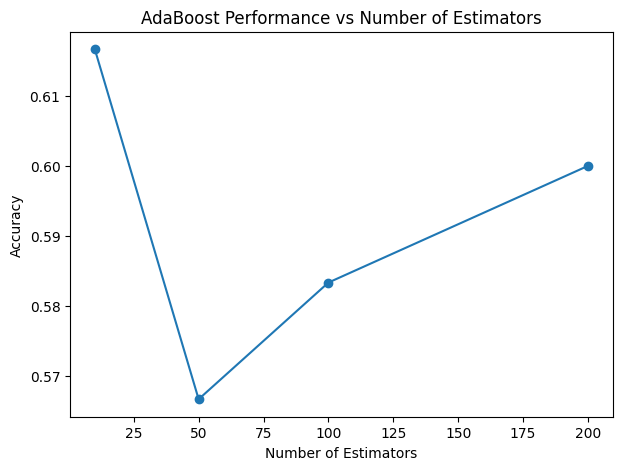

In [ ]:
#plotting the graph
plt.figure(figsize=(7,5))

plt.plot(estimators, accuracy_scores, marker='o')

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance vs Number of Estimators")

plt.show()

**SUBTASK-04**

AdaBoost Implementation: Using AdaBoost from libraries and comparing
classification results with a single Decision Tree.

Kaggle Dataset Link: https://www.kaggle.com/datasets/nikhil1e9/loan-default?

Tasks:
1. Load dataset and preprocess:
Handle missing values
Encode categorical variables
2. Train a Decision Tree classifier.
3. Train an AdaBoost classifier using the same training data.
4. Compare performance using:
Accuracy
Confusion Matrix
Classification Report
5. Explain which model generalizes better and why

In [ ]:
#loading,preprocessing and splitting the dataset
df = pd.read_csv("Loan_default.csv")

df.head()
df = df.dropna()
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
X = df.drop("Default", axis=1)
y = df["Default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
#training decision tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

#training the adboost classifier

stump = DecisionTreeClassifier(max_depth=1)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

# Decision Tree prediction
y_pred_dt = dt_model.predict(X_test)

# AdaBoost prediction
y_pred_ada = ada_model.predict(X_test)

Decision Tree Accuracy: 0.7821229050279329
AdaBoost Accuracy: 0.7932960893854749


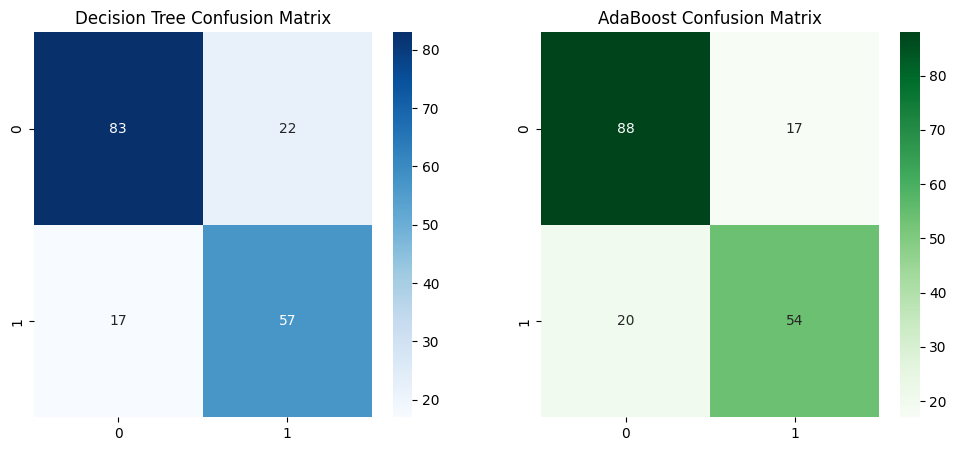

In [40]:
#comparing performance using accuracy confusion matrix
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("AdaBoost Accuracy:",
      accuracy_score(y_test, y_pred_ada))

cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_ada = confusion_matrix(y_test, y_pred_ada)


fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Decision Tree Confusion Matrix")

sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("AdaBoost Confusion Matrix")

plt.show()

In [41]:
#classification report
print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt))

print("AdaBoost Classification Report")
print(classification_report(y_test, y_pred_ada))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179

AdaBoost Classification Report
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



**SUBTASK-05**

AdaBoost Implementation: Using AdaBoost from libraries and comparing
classification results with a single Decision Tree.

Kaggle Dataset Link:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset?

Tasks:
1. Load dataset and preprocess features.
2. Train AdaBoost classifier with different learning rates:
0.01, 0.1, 1.0
3. Evaluate each model using:
Accuracy
Precision, Recall
4. Compare AdaBoost results with a single Decision Tree baseline.
5. Discuss the effect of learning rate on AdaBoost performance.


In [42]:
#loading and preprocessing the dataset
df = pd.read_csv("UCI_Credit_Card.csv")

df.head()
df = df.dropna()
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

In [43]:
#splitting the data and training the decision tree classifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))

Decision Tree Performance
Accuracy: 0.722
Precision: 0.37420269312544296
Recall: 0.4021325209444021


In [44]:
#training the adboost classifier with various estimators or learning rates
learning_rates = [0.01, 0.1, 1.0]

for lr in learning_rates:

    stump = DecisionTreeClassifier(max_depth=1)

    ada_model = AdaBoostClassifier(
        estimator=stump,
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    ada_model.fit(X_train, y_train)

    y_pred = ada_model.predict(X_test)

    print("\nAdaBoost Learning Rate:", lr)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))


AdaBoost Learning Rate: 0.01
Accuracy: 0.8193333333333334
Precision: 0.6886326194398682
Recall: 0.31835491241431835

AdaBoost Learning Rate: 0.1
Accuracy: 0.816
Precision: 0.6856127886323268
Recall: 0.293983244478294

AdaBoost Learning Rate: 1.0
Accuracy: 0.8181666666666667
Precision: 0.6801948051948052
Recall: 0.31911652703731913
